# Options Pricing Project

## Contents

1. [Introduction](#-introduction)
2. [Setup](#-setup)
3. [Analytical Solution](#-analytical-solution)
3. [Benchmarking the numerical models](#-benchmarking-the-numerical-models)
    - [Crank-Nicolson](#-crank-nicolson)
    - [Binomial Tree](#-binomial-tree)

## Introduction
[↑ Back to top](#contents)

The aim of this project is to implement several different ways of pricing options. We will concentrate our efforts to the cases of European and American call and put options. The European case is considered solved, due to the Black-Scholes equation and the corresponding analytical solution but this does not mean it should be discarded. There are several modelling assumptions that are violated in practice. Nonetheless, it is a useful benchmark. The American option is more challenging to price due to the early exercise constraint. To date, no analytical methods have been found to solve this so numerical methods are employed. Our goal here is to implement a Crank-Nicolson finite difference scheme and a binomial tree solver for both European and American  provide a rigourous analysis of their efficacy. This notebook contains demonstrations of the models and documents the benchmarking process. The full mathematical theory behind the analytical solutions, the numerical implementations and more, can be found in the file [`Theory-and-Derivations.md`](./Theory-and-Derivations.md).

## Setup
[↑ Back to top](#contents)

We import our numerical solvers alongside some standard packages necessary for running the notebook here.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from BS_solver import BS_solver_crank_nicolson, BS_solver_binomial_tree

## Analytical Solution
[↑ Back to top](#contents)

Our first benchmark for our models will be comparing them to the analytical solution of the European option. We indicate the key analytic results briefly here. One can show that, under the assumptions of: no dividend payments, a constant risk-free interest rate $r$, stock prices ($S$) follow a geometric Brownian motion and there is a constant volatility $\sigma$, the value of an option, $V$, must satisy the Black-Scholes (BS) equation:
$$
rV = \frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}.
$$
For a call option, this is subject to the boundary and terminal conditions
$$
V(S,T) = \max{(S-K, 0)}, \\
V(0,t)=0, \\
V \sim S-Ke^{-r(T-t)} \text{ as } S \rightarrow \infty,
$$
where $T$ is the maturity date.
The solution can be shown to be
$$
V(S,t) = S\Phi(a) - Ke^{-r(T-t)}\Phi(b),
$$
where
$$
a = \frac{\ln(\frac{S}{K})+(r+\frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T-t}}, \\
b = \frac{\ln(\frac{S}{K}) + (r-\frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}} 
$$
and $\Phi$ is the CDF of the standard normal distribution. See [here](./Theory-and-Derivations.md) for the full derivation of the PDE, its solution and the corresponding conditions for a put option. This provides a useful comparison point for our numerical models.

## Benchmarking the numerical models
[↑ Back to top](#contents)

In this section we will employ several tests of our numerical methods. The following are not intended as rigorous convergence checks (these will come later) but should be thought of as quick sanity checks. We will check:
1. Both the Crank-Nicolson solver and the binomial tree solver agree with the analytic solution for both European calls and puts.
2. We will compare the numeric American call options to their analytic European counterpart. It can be shown that in the case of no dividends, that these two options should be priced equally.
3. We will verify that, for an American put, it's value is always greater than its European counterpart.
4. We further verify that the American put's value satisifes $\max{(K-S, 0)}\leq V(S,t)\leq K$.

Furthermore, we will conduct all of these tests on the Crank-Nicolson method first and then the binomial tree method. The reason for this is simply efficiency: each method computes the value of an option across different shaped grids (a rectangle for the CN method and a tree-like grid for the binomial method) so we save ourself some time in using this order.

### Crank-Nicolson
[↑ Back to top](#contents)

For our first test we will consider a European call and a put with strike price $K=100$, risk-free interest rate $r=0.05$, volatility  $\sigma=0.2$ and maturity date $T=1$ year. The Crank-Nicolson solver must be computed on a finite grid and we must choose a sufficiently large upper bound for the domain otherwise the asymptotic boundary condition will be much less accurate allowing errors to propogate throughout the solution. Thus we choose an upper bound of $400$. Below we produce comparison plots of the analytical and Crank-Nicolson solutions.

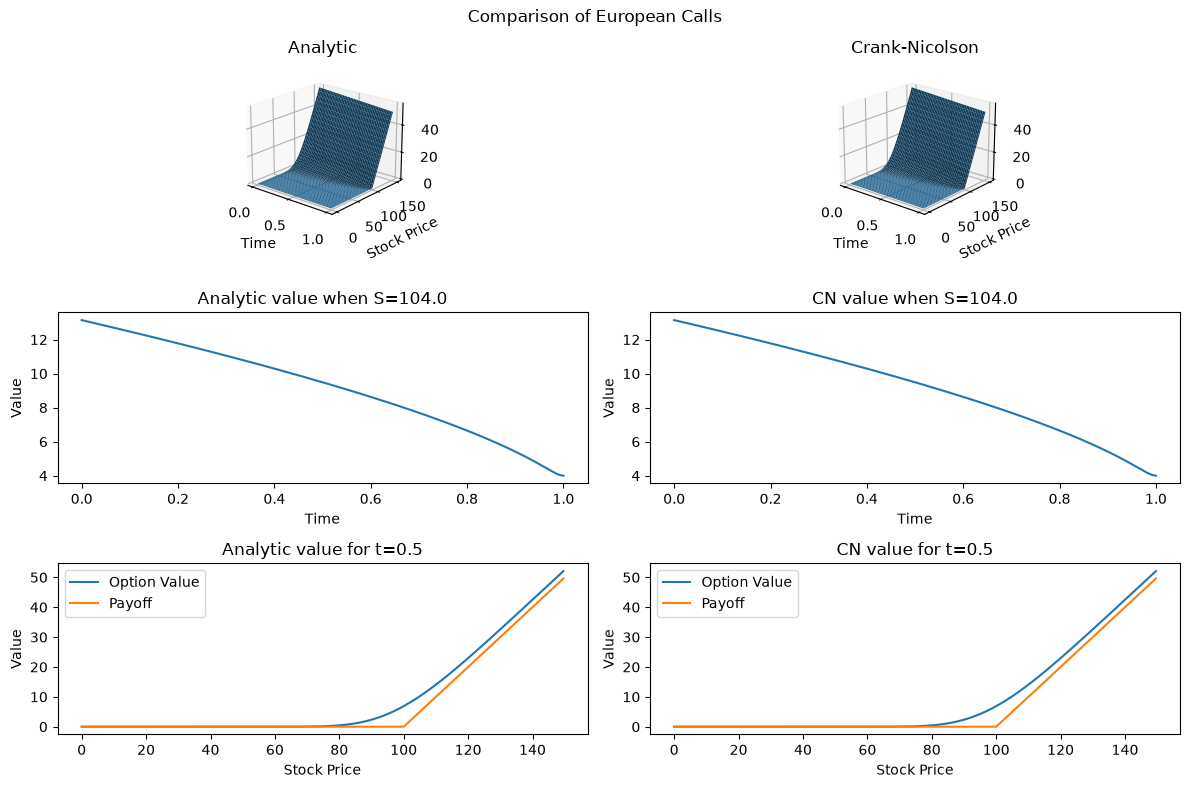

In [2]:
n = 1000
m = 1000
S_upper = 400
T = 1
K = 100
r = 0.05
sigma = 0.2

# Create the time and stock domain
t = np.linspace(0,T,n+1)
S = np.linspace(0,S_upper,m+1)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
# We encounter divison by 0 errors at the terminal condition. We suppress this for aesthetic reasons but note its presence.
with np.errstate(divide='ignore', invalid='ignore'):
    a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
    b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

# Compute the analytic and Crank-Nicolson solutions
V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)
V_analytic_put = -S * sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(-b)
V_CN_call = BS_solver_crank_nicolson(S_upper=S_upper, T=T, K=K, r=r, sigma=sigma, put=False, American=False, m=m, n=n)
V_CN_put = BS_solver_crank_nicolson(S_upper=S_upper, T=T, K=K, r=r, sigma=sigma, put=True, American=False, m=m, n=n)

fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(3, 2, 1, projection='3d')
ax1.plot_surface(t[0:375, :], S[0:375, :], V_analytic_call[0:375, :])
ax1.set_title('Analytic')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=-50)

ax2 = fig.add_subplot(3, 2, 2, projection='3d')
ax2.plot_surface(t[0:375, :], S[0:375, :], V_CN_call[0:375, :])
ax2.set_title('Crank-Nicolson')
ax2.set_xlabel('Time')
ax2.set_ylabel('Stock Price')
ax2.view_init(elev=20, azim=-50)

ax3 = fig.add_subplot(3,2,3)
ax3.plot(t[0], V_analytic_call[260,:])
ax3.set_title(f'Analytic value when S={S[260,0]}')
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')

ax4 = fig.add_subplot(3,2,4)
ax4.plot(t[0], V_CN_call[260,:])
ax4.set_title(f'CN value when S={S[260,0]}')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')

ax5 = fig.add_subplot(3,2,5)
ax5.plot(S[0:375,0], V_analytic_call[0:375, 500])
ax5.plot(S[0:375,0], np.maximum(S[0:375,0]-K, 0))
ax5.set_title(f'Analytic value for t={t[0,500]}')
ax5.set_xlabel('Stock Price')
ax5.set_ylabel('Value')
ax5.legend(['Option Value', 'Payoff'])

ax6 = fig.add_subplot(3,2,6)
ax6.plot(S[0:375,0], V_CN_call[0:375, 500])
ax6.plot(S[0:375,0], np.maximum(S[0:375,0]-K, 0))
ax6.set_title(f'CN value for t={t[0,500]}')
ax6.set_xlabel('Stock Price')
ax6.set_ylabel('Value')
ax6.legend(['Option Value', 'Payoff'])

plt.suptitle('Comparison of European Calls')
plt.tight_layout()
plt.show()

The plots for the calls looks identical at each measured point. For more thoroughness, we examine the maximum absolute difference between the two solutions. We exlcude `nan` values in this calculation due to a handle of division by 0 errors in the analytic code.

In [3]:
# The analytical solution encounters a division by 0 at the terminal condition when t=T and when the S
print( f'Maximum absolute error for European call for Crank-Nicolson method: {np.nanmax(np.abs(V_CN_call-V_analytic_call)) :.3f}' )
print( f'Maximum absolute error for European put for Crank-Nicolson method: {np.nanmax(np.abs(V_CN_put-V_analytic_put)) :.3f}' )

Maximum absolute error for European call for Crank-Nicolson method: 0.020
Maximum absolute error for European put for Crank-Nicolson method: 0.020


We see that, to 3 decimal places, we have a maximum absolute error of 0.020 for the given parameters. When we consider the range of values of the option is $\approx304.9$ this represents an error of $\approx 0.0656\%$. However, for the put option, the maximum value for the option is $100$ leading to a much larger error of $\approx 0.0202\%$.

We now take a look at our second benchmark: comparing the American call to the European one.

In [4]:
V_CN_call = BS_solver_crank_nicolson(S_upper=S_upper, T=T, K=K, r=r, sigma=sigma, put=False, American=True, m=m, n=n)
# The analytical solution encounters a division by 0 at the terminal condition when t=T and when the S
print( f'Maximum absolute error for American call for Crank-Nicolson method: {np.nanmax(np.abs(V_CN_call-V_analytic_call)) :.3f}' )

Maximum absolute error for American call for Crank-Nicolson method: 0.020


Despite using the `American=True` argument, triggering a different block of code in the `BS_solver_crank_nicolson` function, we produce the exact same error as before. This is as should be expected.

We move on to our third and fourth benchmarks, which are applicable to the American put option. We wish to verify that the American put always has greater, or at least equal, value to its European counterpart and that it is bounded above by its strike price and below by its payoff function. When we first compared the numerical method against this criteria it initially failed. Further analysis revealed the presence of `NaN` values near the terminal condition again in the analytical solution which had to be excluded. Visual surface plots of the two solutions did not provide any evidence of the numerical method failing this criteria. It was found that by introducing a small error term, $\epsilon=$, that are inequality was satisifed to within this bound. It was also found that smaller time steps reduced the required size of this error. For $n=1000$ time points, we required $\epsilon=10^{-1}$. This is a notable limitation of our model.

In [5]:
V_CN_put = BS_solver_crank_nicolson(S_upper=400, T=1, K=100, r=0.05, sigma=0.2, put=True, American=True, m=1000, n=1000)
eps = 1e-1
print( f'American put greater than European put for all values: {np.all(np.where(np.isnan(V_CN_put) | np.isnan(V_analytic_put), True, V_CN_put + eps >= V_analytic_put))}' )

American put greater than European put for all values: True


We now check that it is within the strike price and the payoff function.

In [6]:
payoff = np.zeros((m+1, n+1))
for j in range(m+1):
    payoff[:, j] = np.maximum(K - S[:, j], 0)

print( f'American put bounded above by K: {np.all(V_CN_put <= K)}' )
print( f'American put bounded below by payoff: {np.all(V_CN_put >= payoff)}' )

American put bounded above by K: True
American put bounded below by payoff: True


This test is passed with no issued. We move on to the binomial tree solver now.

### Binomial tree
[↑ Back to top](#contents)

Since the nature of the binomial tree solver produces solutions on a different grid, we must recompute our analytical values on the same grid. We choose to store the possible stock prices in a square matrix leaving the strictly lower triangular portion equal to 0. This allows us to make use of NumPy's inbuilt broadcasting and vectorised operations but does come at the expensive of larger memory usage. We compute our analytical solution on a similar such matrix. Here, we consider an initial stock price of $S_0=95$ and $n=1000$ steps. We keep the remaining parameters the same as in the Crank-Nicolson tests. We first compare our binomial tree with the analytic European options.

In [7]:
# Initialise our parameters
n = 1000
S0 = 95
T = 1
K = 100
r = 0.05
sigma = 0.2
dt = T/n
u = np.exp(sigma*np.sqrt(dt))
d = np.exp(-sigma*np.sqrt(dt))

# Create the time and stock domain
t = np.linspace(0, T, n+1)
# The stock domain is an upper-triangular matrix such that moving one place along a row is equivalent to a stock increase by factor u. A movement of one entry to the right and one down is a stock change by factor d.
S = np.array([ np.array([S0*u**(j-i)*d**i for i in range(j+1)]+([0]*(n-j))) for j in range(n+1) ]).T

# Ignore zero division errors in analytic solution at terminal condition
with np.errstate(divide='ignore', invalid='ignore'):
    a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
    b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)

# When computing the put option, we cannot naively calculate it for every grid point. We must keep the lower triangular portion 0. Inputting S=0 for a put option will not porduce a 0 output!
V_analytic_put = np.zeros((n+1, n+1))
for j in range(n+1):
    with np.errstate(divide='ignore', invalid='ignore'):
        a = (np.log(S[0:j+1, j]/K) + (r+sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)
        b = (np.log(S[0:j+1, j]/K) + (r-sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)
    V_analytic_put[0:j+1, j] = - S[0:j+1, j] * sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t[j])) * sp.stats.norm.cdf(-b)

V_BT_call = BS_solver_binomial_tree(S0=S0, T=T, K=K, r=r, sigma=sigma, put=False, American=False, n=n)
V_BT_put = BS_solver_binomial_tree(S0=S0, T=T, K=K, r=r, sigma=sigma, put=True, American=False, n=n)

print( f'Maximum absolute error for European call for Binomial tree method: {np.nanmax(np.abs(V_BT_call-V_analytic_call)) :.3f}' )
print( f'Maximum absolute error for European put for Binomial tree method: {np.nanmax(np.abs(V_BT_put-V_analytic_put)) :.3f}' )

Maximum absolute error for European call for Binomial tree method: 0.043
Maximum absolute error for European put for Binomial tree method: 0.043


For 1000 timesteps, we obtain absolute errors of 0.043. As relative errors, these represent approximately $8.13\times 10^{-5}\%$ errors, a much smaller relative error than the Crank-Nicolson method. The relative error for the put can be computed to be $\approx 0.0431\%$.

We now perform our second benchmark: comparing the American call to the European.

In [9]:
V_BT_call = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=False, American=True, n=1000)
print( f'Maximum absolute error for American call for binomial tree method: {np.nanmax(np.abs(V_BT_call-V_analytic_call)) :.3f}' )

Maximum absolute error for American call for binomial tree method: 0.043


We obtain exactly the same error as we did with the European case, confirming our model passes this benchmark. We now check that the American put is always greater than the European put. We anticipate this time that we may need to soften our inequality by introducing a tolerance term.

In [10]:
V_BT_put = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=True, American=True, n=1000)
eps = 1e-1
print( f'American put greater than European put for all values: {np.all(V_BT_put + eps >= V_analytic_put)}' )

American put greater than European put for all values: True


We verify that the inequality is only satisfied to within a tolerance of `1e-1`, another notable limitation. We check our final benchmark, whether or not our American put is bounded above by the strike price, and below by the payoff function. We first run a loop to compute the payoff function across the domain used by the binomial tree method.

In [11]:
payoff = np.zeros((m+1, n+1))
for j in range(n+1):
    payoff[0:j+1, j] = np.maximum(K - S[0:j+1, j], 0)

eps = 1e-13
print( f'American put bounded above by K: {np.all(V_BT_put <= K)}' )
print( f'American put bounded below by payoff: {np.all(V_BT_put +eps >= payoff)}' )

American put bounded above by K: True
American put bounded below by payoff: True


We find that the upper bound of the strike price requires no tolerance term at all, whilst the lower bound of the payoff function requires a tolerance of `1e-13` to be satisfied. Errors of this order of magnitude or most likely due to floating point arithmetic errors.